# Exploring the SRP092402 expression matrix

Blood RNA-seq from the Tuberculosis Treatment Response Cohort ([refine.bio SRP092402](https://www.refine.bio/experiments/SRP092402)).

This notebook loads the gene-symbol-annotated matrix made by `gene_id_annotation.R`, reports its size, log-scales it, and looks at how much expression varies per gene.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

data_file = Path("../data/SRP092402/SRP092402_Symbols.tsv")
results_dir = Path(".")  # notebooks live in results/, next to their outputs

## Load the data

In [2]:
expression_df = pd.read_csv(data_file, sep="\t", index_col="Ensembl")
annotation_cols = ["first_mapped_symbol", "all_symbols"]
expression_mat = expression_df.drop(columns=annotation_cols)

expression_df.iloc[:5, :5]

,first_mapped_symbol,all_symbols,SRR4784227,SRR4784228,SRR4784229
Ensembl,,,,,
ENSG00000000003,TSPAN6,TSPAN6,0.832934,1.021474,1.289036
ENSG00000000005,TNMD,TNMD,0.084439,0.084194,0.091528
ENSG00000000419,DPM1,DPM1,2.606590,2.621648,3.090105
ENSG00000000457,SCYL3,SCYL3,3.739929,3.670232,4.044081
ENSG00000000460,FIRRM,FIRRM,2.491324,2.411124,2.481271


## Size of the matrix

In [3]:
n_genes, n_samples = expression_mat.shape
print(f"Matrix size: {n_genes:,} genes x {n_samples:,} samples")
print(f"Genes with a gene symbol: {expression_df['first_mapped_symbol'].notna().sum():,}")

Matrix size: 43,363 genes x 909 samples
Genes with a gene symbol: 29,992


## Log-scale and per-gene statistics

Add 1 before taking log2 so values stay non-negative. Then compute each gene's median, min, max, and range (max - min) across all samples.

In [4]:
log_mat = np.log2(expression_mat + 1)

gene_stats = pd.DataFrame({
    "symbol": expression_df["first_mapped_symbol"],
    "median": log_mat.median(axis=1),
    "min": log_mat.min(axis=1),
    "max": log_mat.max(axis=1),
})
gene_stats["range"] = gene_stats["max"] - gene_stats["min"]
gene_stats.to_csv(results_dir / "per_gene_log2_stats.tsv", sep="\t")

gene_stats[["median", "range"]].describe().round(3)

,median,range
count,43363.000,43363.000
mean,1.088,0.955
std,1.157,0.531
min,0.101,0.147
25%,0.103,0.637
50%,0.755,0.911
75%,1.721,1.199
max,7.633,7.421


In [5]:
low = (gene_stats["median"] < 1).sum()
print(f"Genes with median log2 expression < 1: {low:,} ({low / n_genes:.1%})")

print("\nMost highly expressed genes:")
print(gene_stats.nlargest(10, "median")[["symbol", "median"]].round(2).to_string())

print("\nGenes with the widest range across samples:")
print(gene_stats.nlargest(10, "range")[["symbol", "median", "range"]].round(2).to_string())

Genes with median log2 expression < 1: 24,927 (57.5%)

Most highly expressed genes:
                 symbol  median
Ensembl                        
ENSG00000075624    ACTB    7.63
ENSG00000234745   HLA-B    7.53
ENSG00000198804  MT-CO1    7.49
ENSG00000204525   HLA-C    7.46
ENSG00000156508  EEF1A1    7.43
ENSG00000087086     FTL    7.37
ENSG00000204592   HLA-E    7.37
ENSG00000119535   CSF3R    7.28
ENSG00000198886  MT-ND4    7.26
ENSG00000206503   HLA-A    7.26

Genes with the widest range across samples:
                   symbol  median  range
Ensembl                                 
ENSG00000206047     DEFA1    3.34   7.42
ENSG00000188536      HBA2    5.46   7.12
ENSG00000240247     DEFA1    3.08   7.05
ENSG00000196565      HBG2    2.95   6.73
ENSG00000204936     CD177    1.94   6.47
ENSG00000012223       LTF    2.71   6.36
ENSG00000284931       NaN    3.25   6.34
ENSG00000239839     DEFA3    2.86   6.03
ENSG00000158578     ALAS2    5.63   5.59
ENSG00000211955  IGHV3-33    2.05   

## Density of per-gene median expression

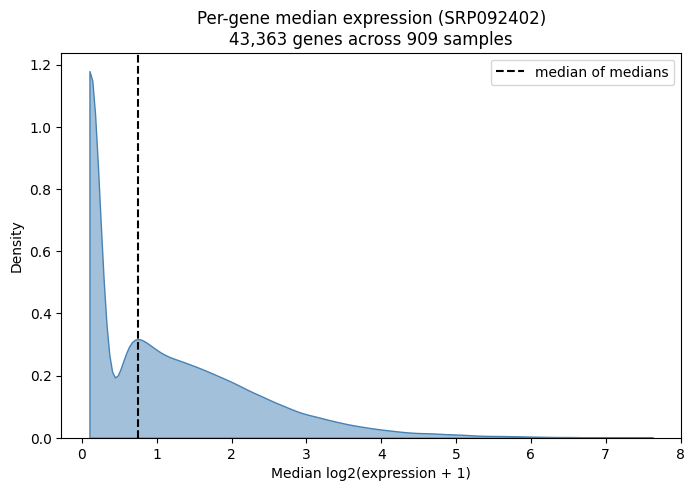

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.kdeplot(gene_stats["median"], fill=True, color="steelblue", alpha=0.5, cut=0, ax=ax)
ax.axvline(gene_stats["median"].median(), linestyle="--", color="black", label="median of medians")
ax.set(
    title=f"Per-gene median expression (SRP092402)\n{n_genes:,} genes across {n_samples} samples",
    xlabel="Median log2(expression + 1)",
    ylabel="Density",
)
ax.legend()
fig.savefig(results_dir / "median_expression_density.png", dpi=150, bbox_inches="tight")
plt.show()

## Density of per-gene expression range

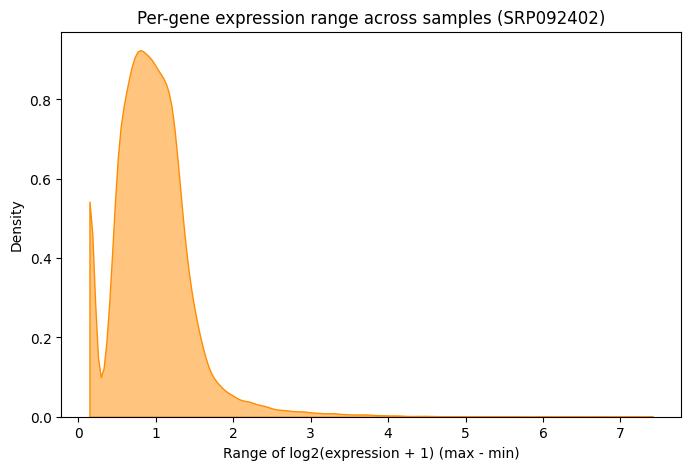

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.kdeplot(gene_stats["range"], fill=True, color="darkorange", alpha=0.5, cut=0, ax=ax)
ax.set(
    title="Per-gene expression range across samples (SRP092402)",
    xlabel="Range of log2(expression + 1) (max - min)",
    ylabel="Density",
)
fig.savefig(results_dir / "expression_range_density.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

- **Size:** 43,363 genes (Ensembl IDs) x 909 samples (SRA runs; about 450 biological samples, since most were sequenced on two lanes). 29,992 genes (69%) have a gene symbol.
- **Two groups of genes in the medians:** a tall spike near the lowest possible value (~0.1), which is genes essentially not expressed in blood, and a broader hump from about 0.5 to 3 of genes that are expressed. 57.5% of genes have a median log2 expression below 1.
- **Long high-expression tail:** a small set of genes reaches a median of about 7.6, as expected for blood. The top genes are housekeeping genes (ACTB, EEF1A1, FTL, mitochondrial MT-CO1 and MT-ND4), immune-presentation genes (HLA-A, -B, -C, -E), and the neutrophil receptor CSF3R.
- **Modest variation for most genes:** the typical gene spans less than 1 log2 unit (about 2-fold) across all samples, partly because quantile normalization puts every sample on the same distribution. A small tail of genes varies by up to about 7 log2 units.
- **What varies most:** neutrophil granule genes (DEFA1, DEFA3, LTF, CD177), which fits the neutrophil-driven immune response in TB, and hemoglobin genes (HBA2, HBG2, ALAS2), which probably reflect uneven globin removal during sample prep rather than biology. These high-variance genes are the most informative for comparing TB patients, controls, and treatment timepoints, but the hemoglobin genes may need to be excluded.
- **Next step:** filter out the low-expression spike (e.g. median < 1) before clustering or differential expression.